# AG-HYPOPT · Trial 14

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirteen trials are registered; cell 2 reports `phase = trials` (13/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). Ranking with mu travel = `lr_mu*(1 - mu_anneal/2)`:

- **trial_08 (0.1099, best, 0 div):** `lr_mu=0.1616`, `mu_anneal=0.3475`, `lr_gamma=0.4157`, `gamma_anneal=0.5318` (travel 0.134).
- **trial_12 (0.1115), trial_09 (0.1126), trial_01 (0.1127), trial_13 (0.1132):** all 0 div, travels 0.128 / 0.123 / 0.120 / 0.134 - the flat optimum cluster.
- **trial_05 (0.1135), trial_07 (0.1140):** travels 0.088 / 0.097.
- **trial_06 (0.1188) / trial_11 (0.1188):** travels 0.082 / 0.159.
- **diverging runs:** trial_10 (0.1975, travel 0.099, diverged at 3nW T60), trial_03 (0.1362, travel 0.074), trial_04 (0.1418, travel 0.074), trial_02 (0.1449, travel 0.264).

State of play: the mu-travel optimum is firmly at ~0.13 (bracketed 0.123-0.159), and trials 08/09/12/13 show the objective there is flat to ~0.003 with no tunable dependence on the gamma schedule. Crucially, the low-travel region below ~0.082 is the only one that has produced divergences (trials 03/04 at 0.074) apart from the erratic trial_10, so it is empirically the least safe part of the space. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_14'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (13/5 trials)
ID |     ei | params
 1 | 2.9537 | {"gamma_anneal": 0.45397712695676234, "lr_gamma": 0.35540598852764815, "lr_mu": 0.18494903949627928, "mu_anneal": 0.3536274871075291}
 2 | 3.2356 | {"gamma_anneal": 0.43095161637674184, "lr_gamma": 0.3976215330799625, "lr_mu": 0.21284726189641362, "mu_anneal": 0.32583225409735095}
 3 | 3.4345 | {"gamma_anneal": 0.5851747627624698, "lr_gamma": 0.46412693158959634, "lr_mu": 0.10936986811252682, "mu_anneal": 0.35057017973590265}
 4 | 3.3825 | {"gamma_anneal": 0.5358132216568752, "lr_gamma": 0.877757215133212, "lr_mu": 0.01958608521635812, "mu_anneal": 0.34927318680875175}
 5 | 3.6398 | {"gamma_anneal": 0.4778054702498448, "lr_gamma": 0.49828134136895796, "lr_mu": 0.17111745770682502, "mu_anneal": 0.36267417761888476}
 6 | 0.5229 | {"gamma_anneal": 0.1655704846658503, "lr_gamma": 0.8279297133153406, "lr_mu": 0.15147701858243728, "mu_anneal": 0.3592379828285713}
 7 | 2.5090 | {"gamma_anneal": 0.5599016622413833, "lr_gamma": 0.

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (13 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 8: **ei 3.87** — `lr_mu=0.084`, `mu_anneal=0.352` (travel **0.069**), `lr_gamma=0.487`, `gamma_anneal=0.440`.
- candidate 5: ei 3.64 — `lr_mu=0.171`, `mu_anneal=0.363` (travel **0.140**), `lr_gamma=0.498`, `gamma_anneal=0.478`.
- candidate 3: ei 3.43 — `lr_mu=0.109`, `mu_anneal=0.351` (travel 0.090), `lr_gamma=0.464`, `gamma_anneal=0.585`.
- candidate 4: ei 3.38 — `lr_mu=0.020`, `mu_anneal=0.349` (travel 0.016, negligible), `lr_gamma=0.878`.
- candidate 2: ei 3.24 — `lr_mu=0.213`, `mu_anneal=0.326` (travel 0.178), `lr_gamma=0.398`.

The single highest-ei candidate (8) sits at travel 0.069 — the one region with a track record of failures: trials 03 and 04 both diverged at travel 0.074, and even trial_06 just above it (0.082) was the weakest of the divergence-free runs at 0.1188. So the top-ei point is the least safe part of the space. The near-tied candidate 5 (ei 3.64) instead sits exactly where the evidence is strongest: travel 0.140, just above the best trial_08 (0.134) and below trial_11 (0.159, which overshot), with a gamma schedule (`lr_gamma=0.498`, `gamma_anneal=0.478`) in the proven-safe range of the divergence-free runs. Given the flat, well-mapped optimum, sampling just past trial_08 is the most informative and lowest-risk way to try to edge below 0.1099, whereas candidate 8 risks another divergence for a region already shown to be poor. Candidates 3/4/2 are less attractive (travel 0.090 near trial_10's divergence; travel 0.016 essentially untested-and-uninformative; travel 0.178 worse). So candidate 5 makes the most sense.

I choose candidate 5 (5 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4778054702498448, 'lr_gamma': 0.49828134136895796, 'lr_mu': 0.17111745770682502, 'mu_anneal': 0.36267417761888476}
Running  1nW Trans05 ... 

μ 9.39 -> 9.73 | γ 8.5 -> 4.28 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 45.18 | γ 8.5 -> 6.14 | NLL 5.75


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 80.78 | γ 14.1 -> 14.52 | NLL 3.31


Running 3nW Trans100 ... 

μ 175.71 -> 111.83 | γ 14.1 -> 14.09 | NLL 3.57



Total: 7.8 min


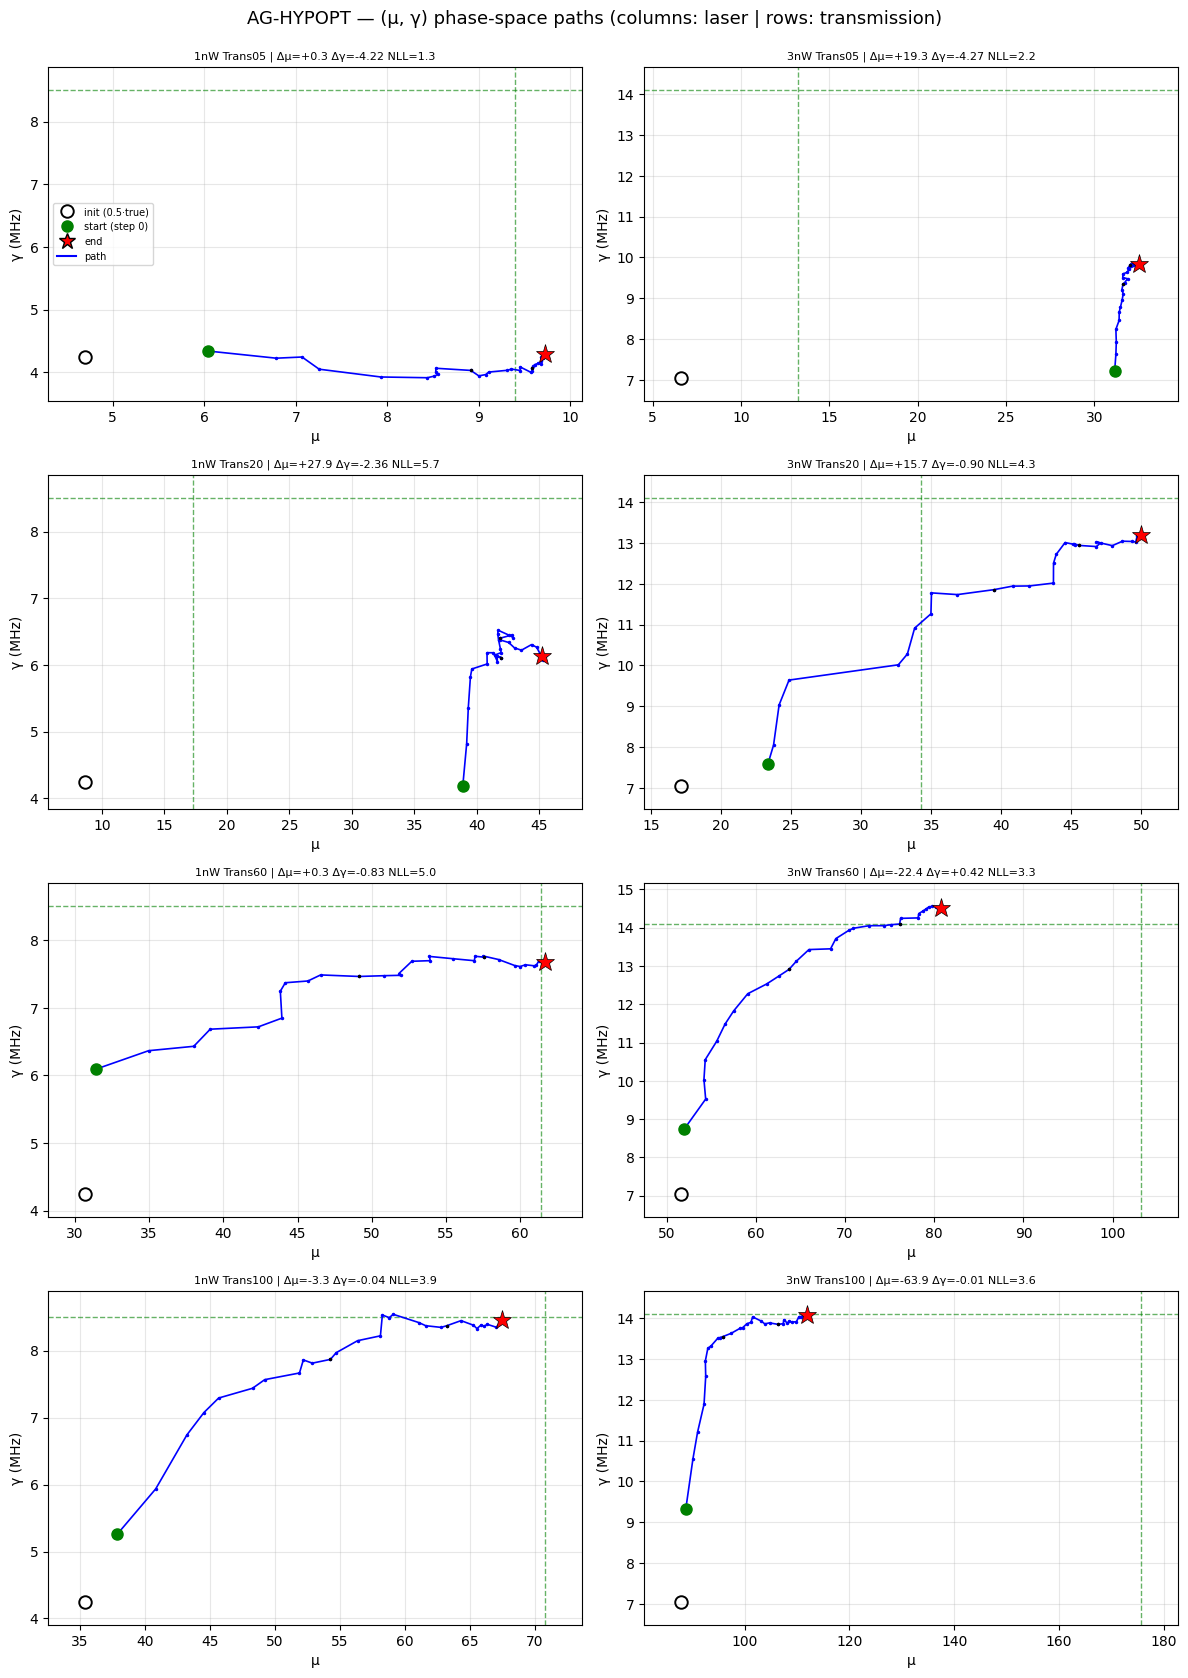

trial finished in 7.8 min
objective = 0.1127 ± 0.0827
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    9.73    +3.5 |     8.50    4.28   -49.6
1nW Trans20       17.32   45.18  +160.9 |     8.50    6.14   -27.8
1nW Trans60       61.37   61.68    +0.5 |     8.50    7.67    -9.7
1nW Trans100       70.82   67.49    -4.7 |     8.50    8.46    -0.5
3nW Trans05       13.20   32.51  +146.2 |    14.10    9.83   -30.3
3nW Trans20       34.28   49.99   +45.8 |    14.10   13.20    -6.3
3nW Trans60      103.20   80.78   -21.7 |    14.10   14.52    +3.0
3nW Trans100      175.71  111.83   -36.4 |    14.10   14.09    -0.1

weighted objective (T-graded, cap=1.0) = 0.1127 | diverged cells: 0
μ: RMSE 27.365 (rel 80.0%, bias -3.263) | γ: RMSE 2.325 (rel 23.2%, bias -1.525)


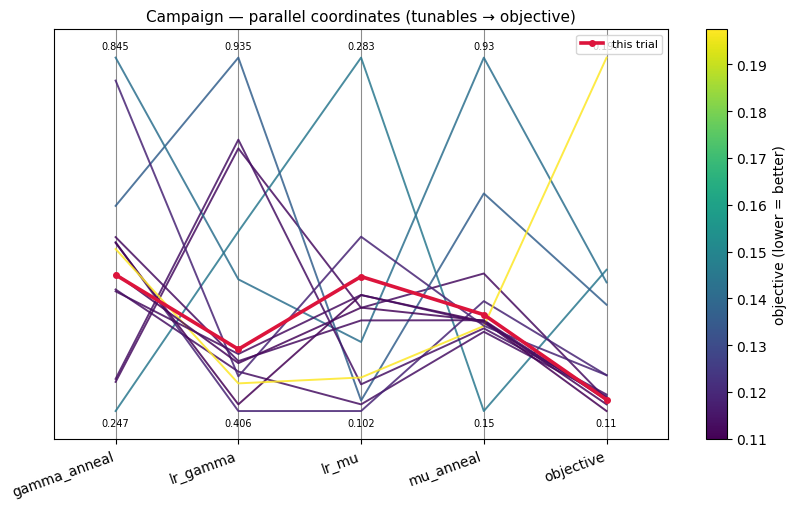

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 14 ran candidate 5 (ei=3.64; I preferred it over the top-ei candidate 8 because candidate 8 sat at travel 0.069, the region where trials 03/04 diverged). Config: `lr_mu=0.1711`, `mu_anneal=0.3627` (effective mu travel 0.140), `lr_gamma=0.4983`, `gamma_anneal=0.4778`. It completed in 7.8 min with objective **0.1127 +/- 0.0827** and **0 diverged cells**. Ranking: trial_08 0.1099 < trial_12 0.1115 < trial_09 0.1126 < trial_01 = **trial_14 0.1127** < trial_13 0.1132 < trial_05 0.1135 < ...

Aggregate accuracy: **mu rel-RMSE 80.0%** (RMSE 27.37, bias -3.26); **gamma rel-RMSE 23.2%** (RMSE 2.33, bias -1.53).

Per-cell relative errors:
- **mu:** 1nW T05 +3.5%, T20 +160.9%, T60 **+0.5%**, T100 -4.7% | 3nW T05 +146.2%, T20 +45.8%, T60 -21.7%, T100 -36.4%.
- **gamma:** 1nW T05 -49.6%, T20 -27.8%, T60 -9.7%, T100 -0.5% | 3nW T05 -30.3%, T20 -6.3%, T60 +3.0%, T100 -0.1%.

This sampled just past trial_08 on the travel axis (0.140 vs 0.134) and it did not improve: the objective came out at 0.1127, level with trial_01. It is a clean, divergence-free run, and its 1nW high-T cells were excellent (T60 +0.5%, T100 -4.7%), but the mid-T overshoots remained large (1nW T20 +160.9%, 3nW T05 +146.2%) and the 3nW high-T undershoot was unchanged. Taken with trial_11 (travel 0.159 -> 0.1188), this confirms the optimum is at ~0.134 and that the objective is flat across travels 0.128-0.140 (0.1099-0.1127). Seven local samples (trials 01, 08, 09, 12, 13, 14) now agree that no small move in the mu or gamma schedule beats trial_08.

**Summary:** Trial 14 (lr_mu=0.1711, mu_anneal=0.3627, lr_gamma=0.4983, gamma_anneal=0.4778): objective 0.1127 +/- 0.0827 with 0 diverged cells; sampling just past trial_08 (travel 0.140) matched trial_01 but did not beat trial_08 (0.1099), with an excellent 1nW T60 (+0.5%) but large mid-T overshoots.
**Key insight:** Travel 0.140 (between trial_08's 0.134 and trial_11's 0.159) lands at 0.1127, so the optimum is confirmed at ~0.134 and the region 0.128-0.140 is flat to ~0.003 - trial_08 remains the best found.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The mid-T mu overshoot (1nW T20 ~+160%, 3nW T05 ~+146%) is now the single largest non-diverged error in every run, capped at rel-sq 1.0 and weighted ~0.4 each; no global schedule has reduced it without harming high T. This is the clearest residual structural limitation; recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 14 (lr_mu=0.1711, mu_anneal=0.3627, lr_gamma=0.4983, gamma_anneal=0.4778): objective 0.1127 +/- 0.0827 with 0 diverged cells; sampling just past trial_08 (travel 0.140) matched trial_01 but did not beat trial_08 (0.1099), with an excellent 1nW T60 (+0.5%) but large mid-T overshoots"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Travel 0.140 (between trial_08's 0.134 and trial_11's 0.159) lands at 0.1127, so the optimum is confirmed at ~0.134 and the region 0.128-0.140 is flat to ~0.003 - trial_08 remains the best found"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_14 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_15.ipynb. Open it and follow its cells from the top.
